### Learning how we can add agentic workflow patterns to our application 
- currently its a naive rag with hybrid retrieval and reranking
- other techniques that allow more difficult queries 
- i.e splitting the queries to run multiple retrieval steps or passes through the db to retrieve more relevant context
- for this we will use agentic workflows
- will introduce agents for RAG and tool use 
- this is a bit harder!

### We will use Lang graph as our agenric workflow engine
lang graph is a:
- an agentic workflow engine 
- llm orchestrator 
- for worklflows
- agents 
- multi agents 
It sits one layer above lang graph 
more of an engine to define the workflows

langgtaph has usefil abstractions for non deterministic agentic applicatons 

Agentic systems built as an execution graphs 
- nodes
- edges

state of graph evolves as the nodes are executed (state machine)


### Import deps

In [3]:
import openai
from pydantic import BaseModel, Field
import pandas as pd

from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage
from IPython.display import Image, display

from typing import Literal, Annotated, Any, List
from operator import add

from jinja2 import Template

import random

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadFieldSchema, PointStruct, Document, Prefetch, FusionQuery, PayloadSchemaType

#### Single Node Graph

In [4]:
class State(BaseModel):
    message: str
    answer: str = ""
    vibe: str

#### Comput function will define a node in the lang graph graph

the state holds all of the variables that can be reached by each node

these varibales will be passed along the graph as the compute happens between nodes

In [5]:
def append_vibes_to_query(state: State) -> dict:

    return {
        "answer": f"{state.message} {state.vibe}"
    }

here we pick up the message and vive from the state and then the answer will be computed and updated

### Workflow

In [6]:
workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)

workflow.add_edge(START, "append_vibes_to_query")

workflow.add_edge("append_vibes_to_query", END)

graph = workflow.compile()

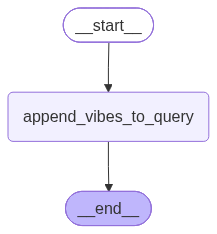

In [7]:
display(Image(graph.get_graph().draw_mermaid_png()))

initial state is sent via the start node, at the end well get the dictionary of output states. I.e in this case message, vibe, answer

In [8]:
initial_state = {
    "message": "give me some vibes", 
    "vibe": "im feeling like my legs are extra long today"    
}

In [9]:
result = graph.invoke(initial_state)

In [10]:
result

{'message': 'give me some vibes',
 'answer': 'give me some vibes im feeling like my legs are extra long today',
 'vibe': 'im feeling like my legs are extra long today'}

in this case we are just testign the graph works, no llm calls etc yet

### Conditional Graph

In [11]:
class State(BaseModel):
    message: str
    answer: str = ""

In [12]:
def append_vibes_to_query(state: State) -> dict:

    return {
        "answer": state.message
    }

In [13]:
def append_vibe_1(state: State) -> dict:

    vibe = "im feeling like my legs are extra long today"    

    return {
        "answer": f"{state.message} {vibe}"
    }

def append_vibe_2(state: State) -> dict:

    vibe = "im feeling like my legs are extra short today"    

    return {
        "answer": f"{state.message} {vibe}"
    }

def append_vibe_3(state: State) -> dict:

    vibe = "im feeling like my legs are the correct length today"    

    return {
        "answer": f"{state.message} {vibe}"
    }

In [14]:
def router(state: State) -> Literal["append_vibe_1", "append_vibe_2", "append_vibe_3"]:

    vibes = ["append_vibe_1", "append_vibe_2", "append_vibe_3"]

    vibe_path = random.choice(vibes)

    return vibe_path

In [15]:
workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    "append_vibes_to_query",
    router,
    {
       "append_vibe_1": "append_vibe_1",
       "append_vibe_2": "append_vibe_2",
       "append_vibe_3": "append_vibe_3"
    }
)

## defining consitional edges explicitly above

workflow.add_edge(START, "append_vibes_to_query")

workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()

In [16]:
initial_state = {
    "message": "How long are my legs"
}

In [17]:
result = graph.invoke(initial_state)

In [18]:
result

{'message': 'How long are my legs',
 'answer': 'How long are my legs im feeling like my legs are extra short today'}

or we can write this like 

In [19]:
workflow = StateGraph(State)

workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    START,
    router,
    {
       "append_vibe_1": "append_vibe_1",
       "append_vibe_2": "append_vibe_2",
       "append_vibe_3": "append_vibe_3"
    }
)

## defining consitional edges explicitly above

workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()

### Exploring Langchain Tool calling 
and eventually building agent loops

(we rarely use langchain apart from when tool calling)
could use pydantic or use openais api or instriuctors structured outputs for this. But this seems to he the best way for multiple toolcalls

In [20]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

any function can be a tool

for this we need:
- type hints 
- proper doc string in the tool so the llm knows which tool to call i.e what the tool does 
- well defined inputs and outpus 
- structure the output to help the llm - which is continuously injected into the message history

In [21]:
@tool
def dummy_tool(a: str, b: str) -> str:
    """Concatenate two strings.

    Args:
        a: The first string to concatenate
        b: The second string to concatenate

    Returns:
        A string of the two strings concatenated.
    """

    return f"Hello {a} and {b}"

In [22]:
llm = ChatOpenAI(
    model="gpt-5.4-mini", 
    reasoning_effort="none",
    use_responses_api=True
)
llm_with_tools = llm.bind_tools(
    [dummy_tool],
    tool_choice="auto"
)

tool choice can be either auto or any. 
auto = allow llm to suggest a tool 
any = can suggest any tool in the tools list

In [23]:
response = llm_with_tools.invoke("use dummy tool to concaotnante two random words")

In [24]:
response

AIMessage(content=[{'arguments': '{"a":"sunshine","b":"banter"}', 'call_id': 'call_igqiDwHsDK56FyGcGqY86DW5', 'name': 'dummy_tool', 'type': 'function_call', 'id': 'fc_06ec410364997d3e006a5ae978a290819bb64ed715f9ac70d7', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_06ec410364997d3e006a5ae9780ed0819bb0e440830eac8122', 'created_at': 1784342904.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_06ec410364997d3e006a5ae9780ed0819bb0e440830eac8122', tool_calls=[{'name': 'dummy_tool', 'args': {'a': 'sunshine', 'b': 'banter'}, 'id': 'call_igqiDwHsDK56FyGcGqY86DW5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 87, 'output_tokens': 25, 'total_tokens': 112, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}})

we can view the toolcalls in the returned object

In [25]:
response.usage_metadata

{'input_tokens': 87,
 'output_tokens': 25,
 'total_tokens': 112,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 0}}

In [26]:
response.tool_calls

[{'name': 'dummy_tool',
  'args': {'a': 'sunshine', 'b': 'banter'},
  'id': 'call_igqiDwHsDK56FyGcGqY86DW5',
  'type': 'tool_call'}]

we will use langchain to simply suggest tool calls
implementing them with langgraph

### Agent Graph

(simple agenet not loop agent)

In [27]:
@tool
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.

    Returns:
        A string with the query and vibe appended.
    """

    return f"{query} {vibe}"

In [28]:
class State(BaseModel):
    query: str
    messages: Annotated[List[Any], add] = []
    iterqtions: int = 0
    answer: str = ""
    final_answers: bool = False

the add reducer appends or extends the list instead of overwriting list items 
`Annotated[List[Any], add] = []`

### Define agent node

In [29]:
def agent_node(state: State) -> dict:

    prompt_template = """You are an assistant that is generating vibes for a user.

## Instructions

- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.

## User Query
{{ query }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.query
    )

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )
    llm_with_tools = llm.bind_tools(
        [append_vibes],
        tool_choice="auto"
    )

    response =  llm_with_tools.invoke(
        [
            SystemMessage(content=prompt)
        ]
    )

    return {
        "messages": [response]
    }

in order to decide if we will invoke tools or not we will use a conditional edge 

In [30]:
def tool_router(state: State) -> str:

    if state.messages[-1].tool_calls:
        return "tools"
    else:
        return "end"

the tool node prvided by langgraph
- prebuilt node
- looks for tool calls in the last mesaages
- with retires
- tool failure logs etc

In [31]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)

workflow.add_edge(START, "agent_node")
workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge("tool_node", END)

graph = workflow.compile()

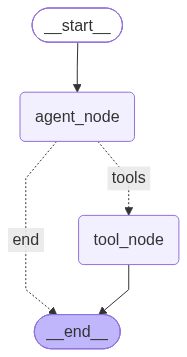

In [32]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
initial_state = {
    "query": "give me some vibes"
}

In [34]:
result = graph.invoke(initial_state)

In [35]:
result

{'query': 'give me some vibes',
 'messages': [AIMessage(content=[{'arguments': '{"query":"give me some vibes","vibe":"with a dreamy, cosmic, neon-lit energy"}', 'call_id': 'call_T30YTDIHdxrIMtPqMRIBRFMS', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_008d8f74906677c6006a5ae97d423c819ba951110a0380d7c6', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_008d8f74906677c6006a5ae97c9768819bbf00d3916f9bbb5b', 'created_at': 1784342908.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_008d8f74906677c6006a5ae97c9768819bbf00d3916f9bbb5b', tool_calls=[{'name': 'append_vibes', 'args': {'query': 'give me some vibes', 'vibe': 'with a dreamy, cosmic, neon-lit energy'}, 'id': 'call_T30YTDIHdxrIMtPqMRIBRFMS', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 140, 'output_tokens': 3

### Now we will implement an agent loop
where the agent can choose multiple tool calls in sequence 
and exit the loop once completed


harnesses are basically loops with guardrails

### Agent Graph With Loopback From Tools (React Agent)

- reasons
- chooses tool calls
- acts against the environment
- reasons about its actions 
- repeat 

In [36]:
@tool
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.

    Returns:
        A string with the query and vibe appended.
    """

    return f"{query} {vibe}"

In [37]:
class FinalResponse(BaseModel):
    answer: str

class State(BaseModel):
    query: str
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

Tools can be functions or pydantic models (a way to return structured outputs)
in this case out llm can call one of two tools 
- append vibes 
- final resposnse 

In [50]:
def agent_node(state: State) -> dict:

    prompt_template = """You are an assistant that is generating vibes for a user.

## Instructions

- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.
- You must return a tool call in the first interaction. 

"""

    template = Template(prompt_template)

    prompt = template.render()

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )
    llm_with_tools = llm.bind_tools(
        [append_vibes, FinalResponse],
        tool_choice="auto"
    )

    response =  llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
            *state.messages
        ]
    )

    final_answer = False
    answer = ""

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")

    return {
        "messages": [response],
        "final_answer": final_answer, 
        "iteration": state.iteration + 1,
        "answer": answer
    }

In [51]:
def tool_router(state: State) -> str:

    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

this loop is limited to 3 loops

In [52]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_edge(START, "agent_node")

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()

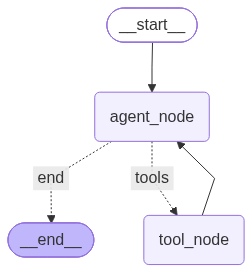

In [53]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [54]:
intial_state = {}

In [55]:
result = graph.invoke(initial_state)

In [56]:
result

{'query': 'give me some vibes',
 'messages': [AIMessage(content=[{'arguments': '{"query":"Hello! How can I help you today?","vibe":"with a random vibe: cozy, upbeat, and a little playful"}', 'call_id': 'call_zcWfLqchU0xoy5fDSmBmNAfE', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_036fb8fd491b5620006a5aea07fe2481998f4a40c3620141fa', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_036fb8fd491b5620006a5aea079078819987bdd7d3d8acb1fc', 'created_at': 1784343047.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_036fb8fd491b5620006a5aea079078819987bdd7d3d8acb1fc', tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Hello! How can I help you today?', 'vibe': 'with a random vibe: cozy, upbeat, and a little playful'}, 'id': 'call_zcWfLqchU0xoy5fDSmBmNAfE', 'type': 'tool_call'}], invalid_tool_calls

the above loop cant see the users previous messages - we fix this by adding the mssages to the list 